In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Graphes
import networkx as nx
import matplotlib.pyplot as plt

# Machine learning classique
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Deep learning - PyTorch & PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx
# Charger les données
data_results = pd.read_csv('EPL_processed_results.csv')

# Convertir la colonne 'Date' en datetime
data_results['Date'] = pd.to_datetime(data_results['Date'])

# Extraire le jour, le mois, l'année et le jour de la semaine
data_results['Day'] = data_results['Date'].dt.day
data_results['Month'] = data_results['Date'].dt.month
data_results['Year'] = data_results['Date'].dt.year
data_results['Weekday'] = data_results['Date'].dt.day_name()  # Ou dt.weekday pour le numéro du jour

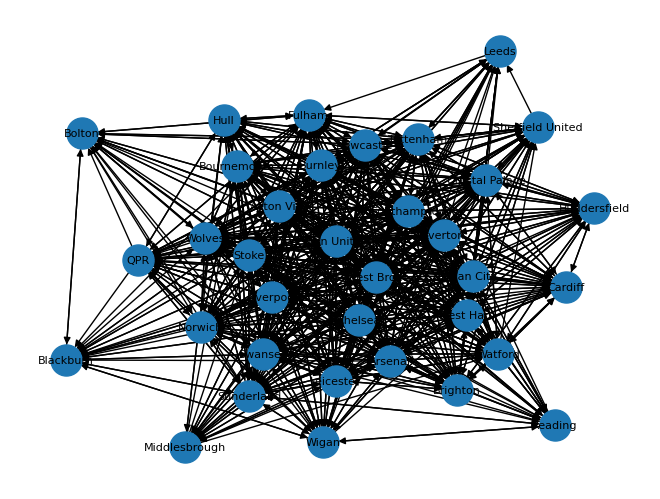

In [2]:


# Charger les données
data_results = pd.read_csv('EPL_processed_results.csv')
data_standings = pd.read_csv('EPL_Standings.csv')

# Convertir les dates
data_results['Date'] = pd.to_datetime(data_results['Date'])
data_results['Day'] = data_results['Date'].dt.day
data_results['Month'] = data_results['Date'].dt.month
data_results['Year'] = data_results['Date'].dt.year
data_results['Weekday'] = data_results['Date'].dt.weekday

# Label encoding de la colonne "Qualification or relegation"
label_encoder = LabelEncoder()
data_standings['QualificationEncoded'] = label_encoder.fit_transform(
    data_standings['Qualification or relegation']
)

# Créer le graphe dirigé
G = nx.DiGraph()

# Étape 1 : Initialiser les nœuds avec tous les attributs manquants
all_seasons = data_standings['Season'].unique()
attributes = ['position', 'points', 'goals_for', 'goals_against', 'goal_diff', 'qualification']
teams = data_standings['Team'].unique()

for team in teams:
    G.add_node(team)
    empty_attrs = {
        f'{attr}_{season}': 0 for season in all_seasons for attr in attributes
    }
    G.nodes[team].update(empty_attrs)

# Étape 2 : Remplir les vraies valeurs à partir de data_standings
for _, row in data_standings.iterrows():
    team = row['Team']
    season = row['Season']
    G.nodes[team][f'position_{season}'] = row['Pos']
    G.nodes[team][f'points_{season}'] = row['Pts']
    G.nodes[team][f'goals_for_{season}'] = row['GF']
    G.nodes[team][f'goals_against_{season}'] = row['GA']
    G.nodes[team][f'goal_diff_{season}'] = row['GD']
    G.nodes[team][f'qualification_{season}'] = row['QualificationEncoded']

# Étape 3 : Ajouter les arêtes entre équipes (de l’extérieur vers le domicile)
for _, row in data_results.iterrows():
    G.add_edge(row['AwayTeam'], row['HomeTeam'],
               day=row['Day'], month=row['Month'], year=row['Year'], weekday=row['Weekday'],
               home_goals=row['HomeGoals'], away_goals=row['AwayGoals'], result=row['FTR'],
               standing_diff=row['StandingDiff'], home_wins=row['HomeWins'], away_wins=row['AwayWins'],
               home_draws=row['HomeDraws'], away_draws=row['AwayDraws'],
               avg_home_goals=row['AvgHomeGoals'], avg_away_goals=row['AvgAwayGoals'],
               avg_home_shots=row['AvgHomeShots'], avg_away_shots=row['AvgAwayShots'],
               avg_home_shots_on_target=row['AvgHomeShotsOnTarget'], avg_away_shots_on_target=row['AvgAwayShotsOnTarget'],
               avg_home_corners=row['AvgHomeCorners'], avg_away_corners=row['AvgAwayCorners'],
               avg_home_goals_conceded=row['AvgHomeGoalsConceded'], avg_away_goals_conceded=row['AvgAwayGoalsConceded'],
               avg_home_shots_conceded=row['AvgHomeShotsConceded'], avg_away_shots_conceded=row['AvgAwayShotsConceded'])

#  Visualiser le graphe
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=500, font_size=8)
plt.show()

In [3]:

# Nettoyage des nœuds : garder uniquement les attributs numériques
for node in G.nodes():
    cleaned_attrs = {
        k: float(v) if not pd.isna(v) else 0.0
        for k, v in G.nodes[node].items()
        if isinstance(v, (int, float, np.number)) or pd.isna(v)
    }
    G.nodes[node].update(cleaned_attrs)

# Nettoyage des arêtes et encodage du résultat
for u, v, attrs in G.edges(data=True):
    cleaned_attrs = {}
    for k, val in attrs.items():
        if isinstance(val, (int, float, np.number)) or pd.isna(val):
            cleaned_attrs[k] = float(val) if not pd.isna(val) else 0.0
        elif k == 'result' and isinstance(val, str):
            cleaned_attrs['label'] = {'H': 0, 'D': 1, 'A': 2}.get(val, -1)
    G[u][v].clear()
    G[u][v].update(cleaned_attrs)

# Conversion vers Data
data = from_networkx(G, group_edge_attrs=True)

# Extraire les labels manuellement
data.y = torch.tensor([G[u][v]['label'] for u, v in G.edges()], dtype=torch.long)

# Créer les features de nœuds
node_feature_keys = [k for k in data.keys() if k.startswith('position_') or 
                     k.startswith('points_') or k.startswith('goal_') or 
                     k.startswith('goals_')]
import torch

node_feature_keys = []
num_nodes = data.num_nodes

for k in data.keys():
    if (k.startswith('position_') or k.startswith('points_') or 
        k.startswith('goal_') or k.startswith('goals_')):

        val = data[k]

        # Ignore les objets qui ne sont ni liste ni Tensor
        if callable(val):
            continue

        try:
            tensor_val = torch.tensor(val, dtype=torch.float)
            if tensor_val.ndim == 1 and tensor_val.size(0) == num_nodes:
                node_feature_keys.append(k)
        except Exception as e:
            print(f"Feature ignorée : {k} — {type(val)} — Erreur : {e}")

# Empile les features propres
data.x = torch.stack([torch.tensor(data[k], dtype=torch.float) for k in node_feature_keys], dim=1)

/var/folders/mn/8kzb8nld6yz1x00ppzbkn5x40000gn/T/ipykernel_61277/2465284690.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor_val = torch.tensor(val, dtype=torch.float)
/var/folders/mn/8kzb8nld6yz1x00ppzbkn5x40000gn/T/ipykernel_61277/2465284690.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data.x = torch.stack([torch.tensor(data[k], dtype=torch.float) for k in node_feature_keys], dim=1)


In [4]:

# On suppose que data.y = étiquettes (0: H, 1: D, 2: A)
y = data.y.numpy()
edge_index = data.edge_index.numpy().T  # [num_edges, 2]

# Préparation des folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(skf.split(edge_index, y))

In [5]:

class CustomGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

def evaluate_model(hidden_channels, lr, dropout, weight_decay, epochs=100):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y = data.y.numpy()
    edge_targets = data.edge_index[1]

    accs, f1s = [], []

    for train_idx, test_idx in skf.split(np.arange(len(y)), y):
        model = CustomGCN(data.x.shape[1], hidden_channels, 3, dropout)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            out = model(data.x, data.edge_index)
            loss = criterion(out[edge_targets][train_idx], data.y[train_idx])
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = out[edge_targets][test_idx]
            pred = logits.argmax(dim=1).cpu()
            true = data.y[test_idx].cpu()

            accs.append(accuracy_score(true, pred))
            f1s.append(f1_score(true, pred, average='weighted'))

    return np.mean(accs), np.mean(f1s)
    

param_grid = {
    'hidden_channels': [32, 64, 128],
    'lr': [1e-2, 5e-3, 1e-3],
    'dropout': [0.1, 0.3, 0.5],
    'weight_decay': [0, 1e-4, 1e-3]
}

best_score = 0
best_params = {}

for h in param_grid['hidden_channels']:
    for lr in param_grid['lr']:
        for d in param_grid['dropout']:
            for wd in param_grid['weight_decay']:
                acc, f1 = evaluate_model(h, lr, d, wd)
                print(f"H:{h} | LR:{lr} | DO:{d} | WD:{wd} → Acc:{acc:.4f} | F1:{f1:.4f}")
                if acc > best_score:
                    best_score = acc
                    best_params = {'hidden_channels': h, 'lr': lr, 'dropout': d, 'weight_decay': wd}

print("\nBest config :", best_params, "with accuracy =", best_score)

H:32 | LR:0.01 | DO:0.1 | WD:0 → Acc:0.2981 | F1:0.1873
H:32 | LR:0.01 | DO:0.1 | WD:0.0001 → Acc:0.3663 | F1:0.2664
H:32 | LR:0.01 | DO:0.1 | WD:0.001 → Acc:0.3685 | F1:0.2270
H:32 | LR:0.01 | DO:0.3 | WD:0 → Acc:0.3994 | F1:0.2721
H:32 | LR:0.01 | DO:0.3 | WD:0.0001 → Acc:0.3291 | F1:0.1910
H:32 | LR:0.01 | DO:0.3 | WD:0.001 → Acc:0.4068 | F1:0.2606
H:32 | LR:0.01 | DO:0.5 | WD:0 → Acc:0.4249 | F1:0.2581
H:32 | LR:0.01 | DO:0.5 | WD:0.0001 → Acc:0.4112 | F1:0.2817
H:32 | LR:0.01 | DO:0.5 | WD:0.001 → Acc:0.4069 | F1:0.2644
H:32 | LR:0.005 | DO:0.1 | WD:0 → Acc:0.4196 | F1:0.2552
H:32 | LR:0.005 | DO:0.1 | WD:0.0001 → Acc:0.3791 | F1:0.2223
H:32 | LR:0.005 | DO:0.1 | WD:0.001 → Acc:0.3823 | F1:0.3147
H:32 | LR:0.005 | DO:0.3 | WD:0 → Acc:0.4058 | F1:0.2983
H:32 | LR:0.005 | DO:0.3 | WD:0.0001 → Acc:0.3949 | F1:0.2759
H:32 | LR:0.005 | DO:0.3 | WD:0.001 → Acc:0.3686 | F1:0.2321
H:32 | LR:0.005 | DO:0.5 | WD:0 → Acc:0.3728 | F1:0.2866
H:32 | LR:0.005 | DO:0.5 | WD:0.0001 → Acc:0.3930 | 

In [6]:
from imblearn.over_sampling import SMOTE
import numpy as np

# On extrait les arêtes et leurs attributs
edges = []
X = []
y = []

for u, v, attrs in G.edges(data=True):
    if 'label' in attrs:
        x = [val for key, val in attrs.items() if isinstance(val, (int, float, np.number)) and key != 'label']
        if len(x) > 0:
            edges.append((u, v))
            X.append(x)
            y.append(attrs['label'])

X = np.array(X)
y = np.array(y)

print("Distribution avant SMOTE :", np.bincount(y))

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Distribution après SMOTE :", np.bincount(y_resampled))

import copy

new_G = nx.DiGraph()
new_G.add_nodes_from(G.nodes(data=True))  # garder les nœuds et leurs features

# Réinjecter les arêtes originales
for (u, v), feats, label in zip(edges, X, y):
    attrs = {f'feat_{i}': val for i, val in enumerate(feats)}
    attrs['label'] = int(label)
    new_G.add_edge(u, v, **attrs)

# Générer des noms fictifs pour les nouvelles arêtes
from random import choice
teams = list(G.nodes)

# Ajouter les arêtes SMOTE synthétiques
for i in range(len(y), len(y_resampled)):
    u, v = choice(teams), choice(teams)
    feats = X_resampled[i]
    label = int(y_resampled[i])
    attrs = {f'feat_{j}': val for j, val in enumerate(feats)}
    attrs['label'] = label
    new_G.add_edge(u, v, **attrs)


Distribution avant SMOTE : [418 197 324]
Distribution après SMOTE : [418 418 418]


In [7]:
from torch_geometric.utils import from_networkx

# Conversion NetworkX vers Data PyG
data = from_networkx(new_G, group_edge_attrs=True)

# Labels cibles
data.y = torch.tensor([new_G[u][v]['label'] for u, v in new_G.edges()], dtype=torch.long)

# Construction des features de nœuds
node_feature_keys = [k for k in data.keys() if k.startswith('position_') or k.startswith('points_') or k.startswith('goal_') or k.startswith('goals_')]

# Vérification et transformation en Tensors
data.x = torch.stack([torch.tensor(data[k], dtype=torch.float) if not isinstance(data[k], torch.Tensor) else data[k].float() for k in node_feature_keys], dim=1)




# Lancer l'optimisation
results = []
best_score = 0
best_params = {}

for h in param_grid['hidden_channels']:
    for lr in param_grid['lr']:
        for d in param_grid['dropout']:
            for wd in param_grid['weight_decay']:
                acc, f1 = evaluate_model(h, lr, d, wd)
                print(f"H:{h} | LR:{lr} | DO:{d} | WD:{wd} → Acc:{acc:.4f} | F1:{f1:.4f}")

                results.append({
                    'hidden_channels': h,
                    'learning_rate': lr,
                    'dropout': d,
                    'weight_decay': wd,
                    'accuracy': acc,
                    'f1_score': f1
                })

                if acc > best_score:
                    best_score = acc
                    best_params = {
                        'hidden_channels': h,
                        'lr': lr,
                        'dropout': d,
                        'weight_decay': wd
                    }

# Convertir en DataFrame
print("\nBest config :", best_params, "with accuracy =", best_score)

H:32 | LR:0.01 | DO:0.1 | WD:0 → Acc:0.3291 | F1:0.1967
H:32 | LR:0.01 | DO:0.1 | WD:0.0001 → Acc:0.3419 | F1:0.2046
H:32 | LR:0.01 | DO:0.1 | WD:0.001 → Acc:0.3479 | F1:0.2419
H:32 | LR:0.01 | DO:0.3 | WD:0 → Acc:0.3360 | F1:0.1802
H:32 | LR:0.01 | DO:0.3 | WD:0.0001 → Acc:0.3429 | F1:0.1948
H:32 | LR:0.01 | DO:0.3 | WD:0.001 → Acc:0.3330 | F1:0.2030
H:32 | LR:0.01 | DO:0.5 | WD:0 → Acc:0.3498 | F1:0.2049
H:32 | LR:0.01 | DO:0.5 | WD:0.0001 → Acc:0.3400 | F1:0.2092
H:32 | LR:0.01 | DO:0.5 | WD:0.001 → Acc:0.3280 | F1:0.1667
H:32 | LR:0.005 | DO:0.1 | WD:0 → Acc:0.3281 | F1:0.2022
H:32 | LR:0.005 | DO:0.1 | WD:0.0001 → Acc:0.3350 | F1:0.1953
H:32 | LR:0.005 | DO:0.1 | WD:0.001 → Acc:0.3468 | F1:0.2271
H:32 | LR:0.005 | DO:0.3 | WD:0 → Acc:0.3340 | F1:0.1971
H:32 | LR:0.005 | DO:0.3 | WD:0.0001 → Acc:0.3350 | F1:0.1966
H:32 | LR:0.005 | DO:0.3 | WD:0.001 → Acc:0.3340 | F1:0.1738
H:32 | LR:0.005 | DO:0.5 | WD:0 → Acc:0.3360 | F1:0.2029
H:32 | LR:0.005 | DO:0.5 | WD:0.0001 → Acc:0.3241 | 